Grupo 7: Edgar Carlos Rodrigues de Oliveira (ecro@cin.ufpe.br)

# **Análise sobre o comportamento dos casos de meninginte na Região Nordeste**

# Resumo

  Esse projeto busca realizar um estudo em relação a disseminação da meniginte, uma grave doença inflamatória que pode levar a morte. Dessa forma, o projeto foca na Região Nordeste e utiliza o modelo SEIRD para analisar o possível comportamento futuro da doença na região, a partir da análise dos dados implementados no modelo e na resolução do sistema de EDOs.Visto isso, os resultados buscam ser analisados em comparação com os dados reais e assim analisar o comportamento dessa doença, que compromete a sáude da sociedade.

#Introdução e Objetivos

Inicialmente, é válido relatar sobre a relevância do estudo da meniginte para a sociedade, sendo o estudo realizado especificamente na Região Nordeste, região que apresentou um salto considerável de casos (67 -> 688), de 2022 para 2023. Sendo uma doença de fácil contágio, como o simples contato ou proximidade com pessoas infectadas, e a sua severa agressão ao corpo humano, podendo levar até a morte. Se torna importante o debate e estudo sobre os casos de contágio que, inclusive, ocorreu com um estudante de Ciências Biológicas da UFPE em 2023, Guilherme, que contraiu a doença e, após três dias do diagnóstico tratamento intensivo, não aguentou e veio a óbito. Dessa forma, com esse triste exemplo, vemos como essa doença pode ser fatal e severa e, ao mesmo tempo, como ela não está distante da nossa realidade.
Com essa abordagem inicial, agora podemos expor o modelo que será utilizado para o estudo desse caso, que é o SEIRD. Tal modelo é caracterizado pelos seguintes parâmetros:

S: Suscetíveis, pessoas que não possuem imunidade ao vírus;   
E: Expostas , não apresentam sintomas, nem transmitem o vírus;  
I: Infectadas, estão doentes podem transmitir, internar-se , recuperar-se ou morrer.  
R: Recuperadas, foram vacinadas.
D: Mortas, vinheram a óbito.

Além disso, temos como unidades dos parãmetros:

Taxa de Transmissão (beta):taxa de infectados pela doença
Unidade: por pessoas

Taxa de Incubação (sigma):taxa de infectados que podem propagar a doença
Unidade: por pessoas

Taxa de Recuperação (gamma): taxa de recuperados da doença
Unidade: por pessoas

Taxa de Mortalidade (mu): taxa de pessoas que vinheram a óbito
Unidade: por pessoas

Por fim deste tópico, mediante os dados e relatos apresentados, conseguimos entender a relevância de todo esse estudo sobre o desenvolvimento dessa doença na Região Nordeste, a qual envolve a situação da saude da sociedade.

As equações diferenciais foram tiradas do trabalho de [Monografia](https://www.ime.unicamp.br/~mac/db/2020-1S-167296.pdf ) de FELIPE R. R. A. PASSARELLA apresentada ao Instituto de Matemática, Estatística e Computação Científica da Universidade Estadual de Campinas.

Refeência dos dados de meniginte - [DataSus](http://tabnet.datasus.gov.br/cgi/tabcgi.exe?sinannet/cnv/meninbr.def)

Referência sobre o caso do estudante - [CasoUFPE](https://www.cbnrecife.com/artigo/estudante-da-ufpe-morre-por-meningite-bacteriana-saude-investiga-se-obito-foi-por-forma-mais-grave-da-doenca)




> **Mapa Mental**




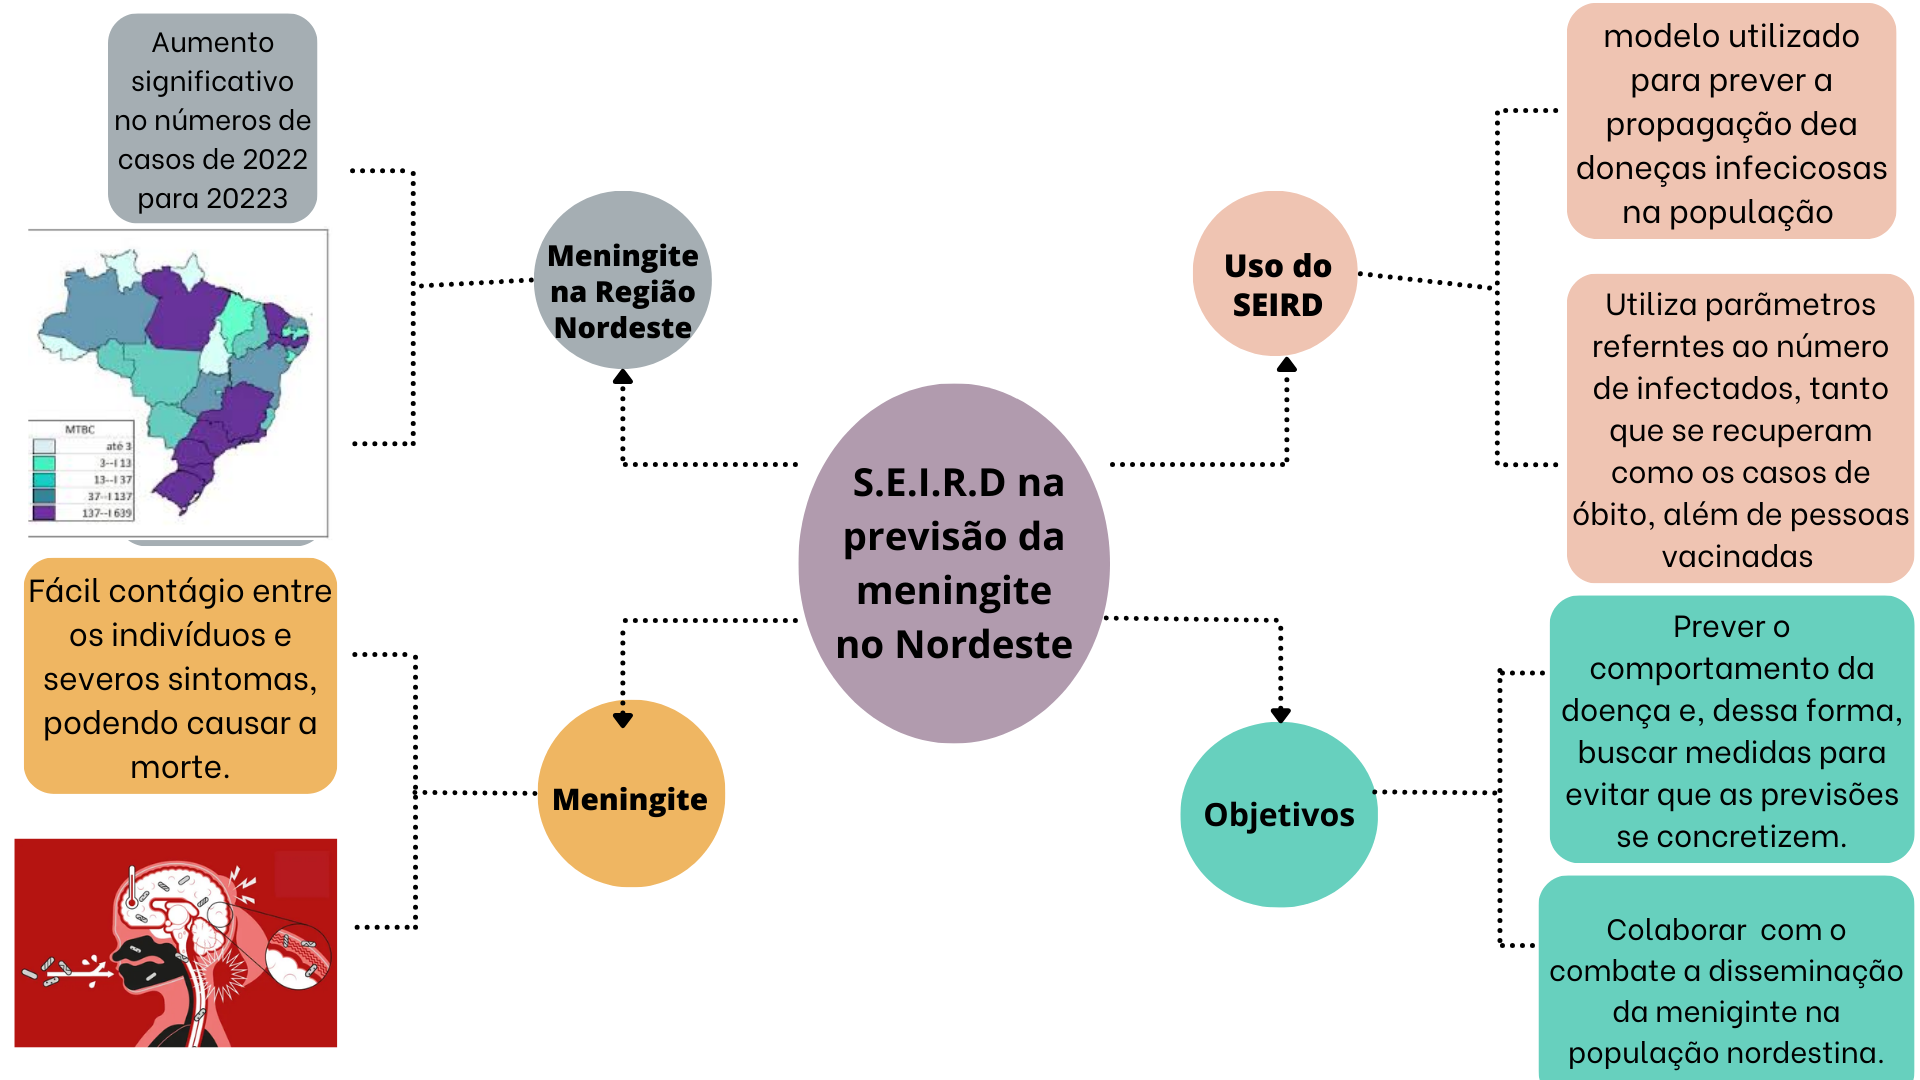







#Modelo
Nesse projeto será utilizado o modelo epidemológico SEIRD, caracterizado por:

S: Suscetíveis, não possuem imunidade ao vírus.   
E: Expostas , não apresentam sintomas, nem transmitem o vírus.   
I: Infectadas, estão doentes, podem transmitir, internar-se , recuperar-se ou morrer.  
R: Recuperadas, foram vacinadas.  
D: Mortas (do inglês: Dead).
A relação entre o número de pessoas em cada categoria é dada por equações diferenciais influenciadas pelos seguintes fatores (considerados constantes):

Período de incubação: tempo para um indivíduo ser exposto a infecção.   
Taxa de infecção : taxa de conversão de Suscetíveis em Expostos.    
Taxa de internação : taxa relacionada com a internação de infectados.   
Tempo internado : tempo que infectado permanece internado.    
Tempo doente: tempo que infectado demora para ser recuperado.   
Mortalidade (letalidade): razão de mortos sobre infectados internados.!

Diante dessas informações, é válido considerar possíveis falhas e limitações (que estão em alteração até a análise final), tais como:

**.** Impactos de medidas sanitárias, como isolamento de infectados, que podem diminuir a probabilidade de um suscetível tornar-se infectado;  
**.** Desconsiderar mutações e variantes do vírus, que podem alterar todas as constantes;
**.** Considerar a taxa de infecção como constante, visto que a própria taxa possui muitas dependências que influenciam em seu valor. Não estamos considerando suas variações parar o futuro.

> Fluxograma


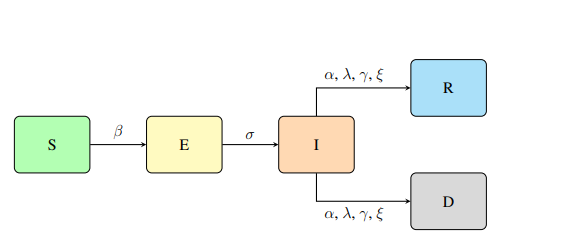

>> Sistema de Equações Diferenciais

As equações que relacionam as quantidades de pessoas em cada categoria no tempo,  foram retiradas da [Monografia](https://www.ime.unicamp.br/~mac/db/2020-1S-167296.pdf ) (página 10) e estão no sistema abaixo:

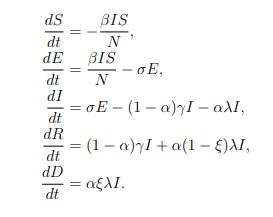




1 - O número de pessoas suscetíveis diminui (por isso o sinal " − ") com o contato entre infectados e suscetíveis (indicado pelo produto  IS ) . A constante  β  (taxa de infecção) está relacionada com a tendência do contato com infectado infectar um suscetível.

2 - Note que βIS / N é a variação (negativa) de S no tempo, isto é, o número de pessoas expostas aumenta com a diminuição de pessoas suscetíveis. σE indica que o número de expostos diminui a medida que o período de incubação (relacionado a constante σ) termina e o indivíduo exposto adoece (torna-se infectado).

3 - O número de pessoas infectadas aumenta com o final do período de incubação (σE) dos expostos, e diminui com a melhora (ou morte) dos infectados.
-- Os que não precisaram ir ao hospital ( (1−α)I ) melhoram a uma taxa γ.
-- Os que precisaram ir ao hospital (αI) melhoram (ou morrem) a uma taxa λ, que está relacionada ao tempo de internação.

4 - O número de recuperados aumenta com a melhora tanto dos infectados que não se internaram ((1−α)γI) , como a dos que se internaram (α(1−ξ)λI). ξ é a letalidade, portanto (1−ξ) ésta relaciondo com os internados que não morreram.

5 - O número de mortos aumenta com a tendência dos infectados (I) a piorarem e precisarem de internação (α), não resistirem a doença (ξ) e sairem do hospital a uma taxa (λ).

# Código

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

In [ ]:
class SEIRD:

    # valores default são relacionados
    # aos dados obtidos nas fontes descritas ao final
    def __init__(self,
                 periodo_incubacao    = 3.5,
                 taxa_infeccao        = 0.69,
                 taxa_internacao      = 0.24,
                 Tempo_internado      = 8.5,
                 Tempo_doente         = 3.5,
                 mortalidade          = 0.02,
                 y0 = (54600000 - 1, 0,1,0,0)):     # y0 = (S0,E0,I0,R0,D0)

        self.β  =  taxa_infeccao            # o quanto tende uma pessoa exposta a ficar doente
        self.σ  = 1/periodo_incubacao       # taxa de incubacao (tempo médio)
        self.γ  = 1/Tempo_doente            # 1/(tempo doente que não foi ao internado)
        self.λ  =  1/Tempo_internado        # 1/(tempo  doente que ficou internado)
        self.α  = taxa_internacao           # o quanto um infectado tende a internar-se
        self.ξ  = mortalidade               # taxa mortalidade do hospital
        self.y0 = y0                        # condições iniciais
        self.y = None                       # solução do sistema de equações: y = (S,E,I,R,D)


    def solve(self):

        def equacao(y, t, N, beta, sigma, alpha, gamma, Lambda, csi):
            S,E,I,R,D     =  y
            β, σ, α, γ, λ, ξ =  beta, sigma, alpha, gamma, Lambda, csi

            dSdt = -β*I*S/N                 # Suscetiveis diminui com o numero de infectados
            dEdt = β*I*S/N - σ*E            # Expostos aumentam se temos muitos infectados e diminui quando ficam infectados
            dIdt = σ*E - (1-α)*γ*I - α*λ*I  # Infectados aumentam com mais exposição e diminuem com recuperacao
            dRdt = (1-α)*γ*I + α*(1-ξ)*λ*I  # Recuperados aumentam com recuperacoes em casa e alta do hospital
            dDdt = α*ξ*λ*I                  # Mortos aumentam com infectados que foram internados morreram no hospital

            return np.array( [dSdt, dEdt, dIdt, dRdt, dDdt] )

        def to_int(V):
            return np.array(list(int(v) for v in V))

        #guardamos a solucao
        S,E,I,R,D = odeint( equacao,
                            self.y0,
                            np.linspace(start = 0, stop = 365*3, num = 365*3),
                            args = (
                                    54600000, #numero de habitantes
                                    self.β,
                                    self.σ,
                                    self.α,
                                    self.γ,
                                    self.λ,
                                    self.ξ
                                    )
                    ).T #transposing

        #casting to int
        self.y = np.array([to_int(S), to_int(E), to_int(I), to_int(R), to_int(D)])


    def plot(self):
        #se ainda nao solucionamos,
        #usamos a funcao solve
        if self.y is None: self.solve()

        color = ['g','y','r','c','black']
        #plot em S,E,I,R,D
        for i,Var in enumerate(self.y):
            plt.plot(np.linspace(start = 0, stop = 365*3, num = 365*3),Var, color[i])

        plt.legend("SEIRD")
        plt.xlabel("dia")
        plt.ylabel("populacao")

    def plotInfectadosMortos(self):
        plt.plot(np.linspace(start = 0, stop = 365*3, num = 365*3),self.y[2], 'r')
        plt.plot(np.linspace(start = 0, stop = 365*3, num = 365*3),self.y[-1],'black')

        plt.legend("ID")
        plt.xlabel("dia")
        plt.ylabel("populacao")

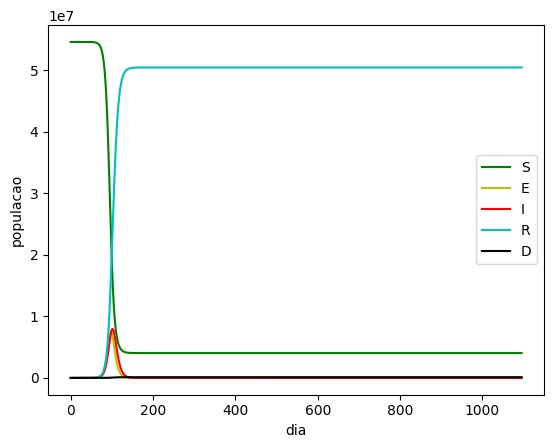

In [ ]:
#modelo usando dados das fontes
modelo = SEIRD()
modelo.plot()

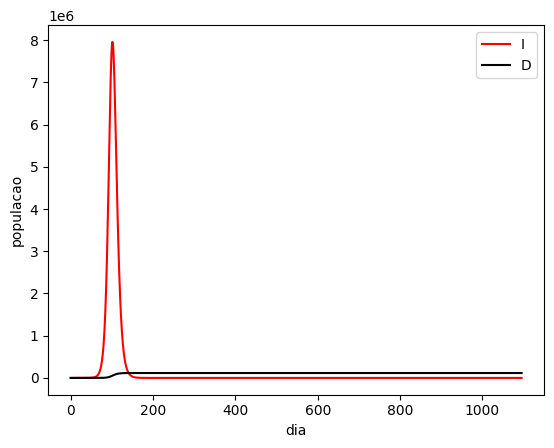

In [ ]:
modelo.plotInfectadosMortos()

In [ ]:
columns =  np.array(['S','E','I','R','D'])
rows    =  np.arange(0,365*3)
df = pd.DataFrame(data= modelo.y.T,index = rows, columns =columns) #criando DAtaFrame dos valores previstos
df

,S,E,I,R,D
0,54599999,0,1,0,0
1,54599998,0,0,0,0
2,54599997,0,0,0,0
3,54599997,1,0,0,0
4,54599996,1,1,0,0
...,...,...,...,...,...
1090,4039333,0,0,50444308,116358
1091,4039333,0,0,50444308,116358
1092,4039333,0,0,50444308,116358
1093,4039333,0,0,50444308,116358


Como vemos abaixo, o modelo com tais parâmetros não simula bem a realidade, pois em 395 dias (um ano e um mês aproximadamente) não haveriam mais infectados, com o fim da crise. Além disso, o número de mortos está bem mais elevado do que o atual.

In [ ]:
df.iloc[390:400]

,S,E,I,R,D
390,4039333,0,0,50444308,116358
391,4039333,0,0,50444308,116358
392,4039333,0,0,50444308,116358
393,4039333,0,0,50444308,116358
394,4039333,0,0,50444308,116358
395,4039333,0,0,50444308,116358
396,4039333,0,0,50444308,116358
397,4039333,0,0,50444308,116358
398,4039333,0,0,50444308,116358
399,4039333,0,0,50444308,116358


A monografia apresenta outros parâmetros, porém também não se adequão bem aos dados da Região Nordeste.

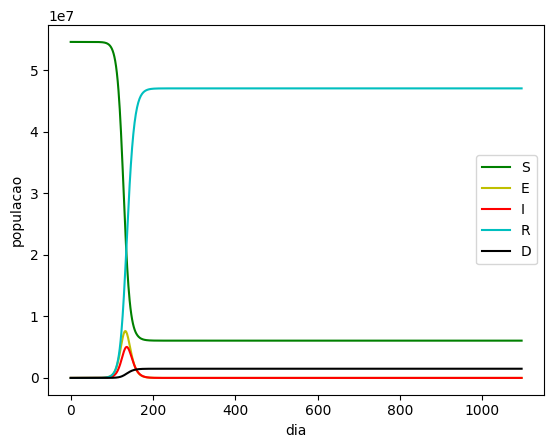

In [ ]:
modeloMonografia = SEIRD()

modeloMonografia.σ = 0.192
modeloMonografia.α = 0.2
modeloMonografia.ξ = 0.3
modeloMonografia.λ = 0.143
modeloMonografia.γ = 0.313

modeloMonografia.plot()

In [ ]:
columns =  np.array(['S','E','I','R','D'])
rows    =  np.arange(0,365*3)
df = pd.DataFrame(data= modeloMonografia.y.T,index = rows, columns =columns) #criando DataFrame dos valores previstos
df.iloc[390: 400]

,S,E,I,R,D
390,6057450,0,0,47049735,1492813
391,6057450,0,0,47049735,1492813
392,6057450,0,0,47049735,1492813
393,6057450,0,0,47049735,1492813
394,6057450,0,0,47049735,1492813
395,6057450,0,0,47049735,1492813
396,6057450,0,0,47049735,1492813
397,6057450,0,0,47049735,1492813
398,6057450,0,0,47049735,1492813
399,6057450,0,0,47049735,1492813


Podemos tentar melhorar as previsões modificando o parâmetro β e a letalidade:

In [ ]:
modelo.β = 0.30
modelo.ξ = 0.01
modelo.solve()
columns =  np.array(['S','E','I','R','D'])
rows    =  np.arange(0,365*3)
df = pd.DataFrame(data= modelo.y.T,index = rows, columns =columns) #criando DataFrame dos valores previstos
df.iloc[390: 400]

,S,E,I,R,D
390,54294784,26787,28084,250055,288
391,54286284,27522,28857,257039,296
392,54277552,28276,29651,264215,304
393,54268580,29051,30465,271589,312
394,54259364,29846,31302,279165,321
395,54249897,30662,32160,286949,330
396,54240172,31499,33042,294946,339
397,54230182,32358,33946,303162,349
398,54219921,33240,34875,311603,358
399,54209381,34145,35828,320275,368


Vemos aqui que o número de mortos e recuperados ficou mais equilibrado. Porém, a análise a partir de determinado tempo pode ter um comportamento bem diferente do mostrado, pois ao longo do tempo podemos ter fatores das variações do vírus e dos processos de vacinação.

**Outros modelos para análise hipotética de vírus com características diferentes**

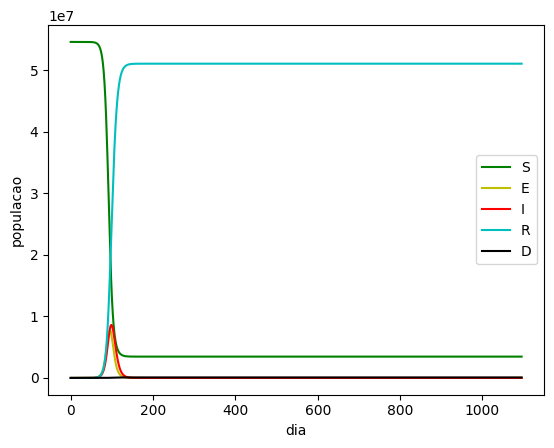

In [ ]:
modelo2 = SEIRD(Tempo_internado = 14)
modelo2.plot()

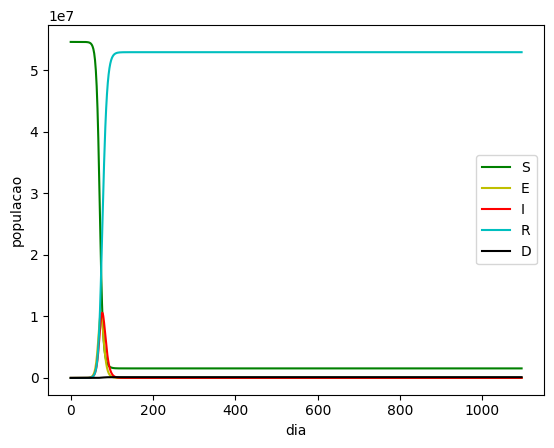

In [ ]:
modeloContagioso = SEIRD(taxa_infeccao= 0.9)
modeloContagioso.plot()

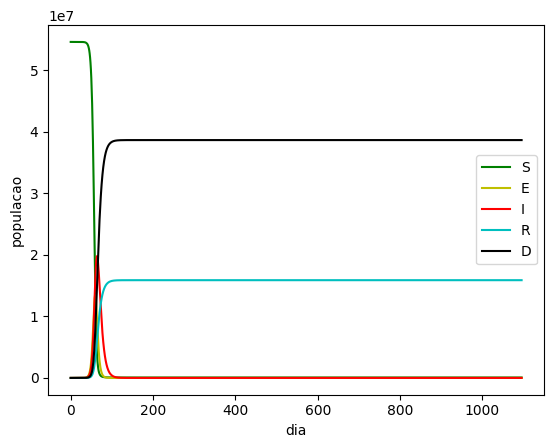

In [ ]:
modeloPerigoso = SEIRD(taxa_infeccao=0.9,mortalidade=0.9,taxa_internacao=0.9)
modeloPerigoso.plot()

#Conclusões

Com a proposta e desenvolvimento do projeto, foi possível analisar os diferentes cenários que a meninginte pode ter na Região Nordeste e, com isso, possibilitar uma posssível contribuição a saúde populacional de diminuir e combater o crescimento dessa doença. Além disso, houve um grande estudo e aprendizado sobre o modelo SEIRD e as EDOs utilizadas, que proporcionou um positivo conhecimento pessoal.

**Fontes**

[periodo de incubação] e [tempo doente] = https://www.saude.ba.gov.br/suvisa/vigilancia-epidemiologica/doencas-imunopreveniveis/meningites/#:~:text=O%20per%C3%ADodo%20de%20incuba%C3%A7%C3%A3o%20%C3%A9,influenzae%20tipo%20b%20e%20Doen%C3%A7a%20Meningoc%C3%B3cica.

[taxa de infecção] = https://www.gov.br/saude/pt-br/assuntos/saude-de-a-a-z/m/meningite/situacao-epidemiologica#:~:text=Entre%20os%20anos%20de%202010,caso%2F100.000%20hab.

[taxa de internação] = https://www.bjid.org.br/en-internacoes-por-meningite-viral-no-articulo-resumen-S1413867023007237

[tempo internado] = https://www.fhemig.mg.gov.br/sala-de-imprensa/noticias-sala-imprensa/2055-meningite-e-grave-e-pode-ser-evitada

[taxa de mortalidade] = https://www.bjid.org.br/en-taxa-de-letalidade-da-meningite-articulo-S1413867023004944

[quantidade de habitantes] = https://demografiaufrn.net/2023/07/12/censo-demografico-2022-reflexoes-iniciais-sobre-a-regiao-nordeste/